This project performed Exploratory Data Analysis (EDA) on the customer sales dataset.
Different statistical methods and visualizations were used to identify trends,
patterns, correlations, and outliers. The analysis helped understand customer
behavior, sales performance, and payment trends, providing meaningful business insights.

Skills Demonstrated
Data Cleaning
Data Visualization
Statistical Analysis
Business Insight Generation
Analytical Thinking
Python for Data Analytics

In [175]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

STEP 1: LOAD FILE AND INSPECT

In [176]:

df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [177]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [178]:
df.shape

(1200, 14)

In [179]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


 we can see that CouponCode has missing values  and date is not date formart

In [181]:
df.isna().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

STEP 2. HANDLING MISSING VALUES USING FILLNA AND DROPNA BASED ON CONDITION

In [182]:
df['CouponCode'].unique()

array(['SAVE10', 'FREESHIP', nan, 'WINTER15'], dtype=object)

In [183]:
df['CouponCode'].fillna(df['CouponCode'].mode()[0], inplace=True)

C:\Users\sbdsa\AppData\Local\Temp\ipykernel_22080\3495395919.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CouponCode'].fillna(df['CouponCode'].mode()[0], inplace=True)


In [184]:
df['CouponCode'].unique()

array(['SAVE10', 'FREESHIP', 'WINTER15'], dtype=object)

In [185]:
df.duplicated().sum()

np.int64(0)

In [186]:
df.drop_duplicates(inplace=True)

STEP 3. DATA FORMATTING and date type

In [187]:
df['Date'] = pd.to_datetime(df['Date'])
print(df['Date'].dtype)

datetime64[ns]


In [188]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

project 2.1 : Task - Descriptive Analysis

In [189]:
# Shows the average amount customers spend.

df['TotalPrice'].mean()

np.float64(1053.9683)

In [190]:
df['TotalPrice'].median()

823.615

In [191]:
df['TotalPrice'].min() #minimum total price

11.39

In [192]:
df['TotalPrice'].max() #maxmimum total price

3456.4

In [193]:
df['TotalPrice'].std()

819.8565583646451

In [194]:
df['TotalPrice'].count()

np.int64(1200)

In [195]:
df['TotalPrice'].mode()

0     211.14
1     367.34
2     410.52
3     635.90
4    2517.36
Name: TotalPrice, dtype: float64

1. Group  BY  examples

In [196]:

df.groupby('Product')['TotalPrice'].mean()

Product
Chair      1098.989382
Desk        985.058412
Laptop     1110.558150
Monitor    1077.616012
Phone       972.579423
Printer    1080.732652
Tablet     1042.284637
Name: TotalPrice, dtype: float64

In [197]:
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

2. find out maximum ReferralSource rows

In [198]:
df['ReferralSource'].value_counts().idxmax()

'Instagram'

In [199]:
#how many times it appears
max_referal = df['ReferralSource'].value_counts().max()
max_referal

259

In [200]:
max_referal = df['ReferralSource'].value_counts().idxmax()

df[df['ReferralSource'] ==  max_referal]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1,4
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72,2023,10,23
10,ORD200010,2023-12-29,C43443,Tablet,5,625.97,333 Main St,Credit Card,Returned,TRK98859248,9,WINTER15,Instagram,3129.85,2023,12,29
14,ORD200014,2023-03-27,C98474,Tablet,2,393.33,980 Main St,Debit Card,Pending,TRK79186539,3,SAVE10,Instagram,786.66,2023,3,27
20,ORD200020,2023-05-08,C54829,Chair,5,62.51,587 Main St,Cash,Pending,TRK16718651,9,WINTER15,Instagram,312.55,2023,5,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190,ORD201190,2025-06-08,C46886,Desk,3,616.39,754 Main St,Credit Card,Shipped,TRK82791646,6,FREESHIP,Instagram,1849.17,2025,6,8
1191,ORD201191,2025-02-10,C44148,Desk,4,376.43,809 Main St,Gift Card,Pending,TRK67872709,5,WINTER15,Instagram,1505.72,2025,2,10
1192,ORD201192,2024-02-28,C72007,Chair,3,432.85,999 Main St,Online,Pending,TRK16240916,4,FREESHIP,Instagram,1298.55,2024,2,28
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68,2023,7,13


3. 

In [201]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [202]:

df.groupby('Product')['PaymentMethod'].idxmax()

Product
Chair      33
Desk       40
Laptop     24
Monitor    11
Phone       1
Printer     4
Tablet     50
Name: PaymentMethod, dtype: int64

In [203]:

df.groupby('Product')['PaymentMethod'].max()

Product
Chair      Online
Desk       Online
Laptop     Online
Monitor    Online
Phone      Online
Printer    Online
Tablet     Online
Name: PaymentMethod, dtype: object

Insights:   Online product has dominate over other paying method.

3. monthly sales


In [204]:
df.groupby('Month')['TotalPrice'].sum().sort_values(ascending=False)

Month
6     170616.13
5     135142.59
1     124313.23
3     123840.93
2     112344.78
4     109186.05
10     89834.82
8      86343.21
7      85784.64
12     82540.50
11     75493.43
9      69321.65
Name: TotalPrice, dtype: float64

Insights: Most of the sales increased during 6th, 5thand 1st months.

Visualiztion

1. Bivariate Analysis and visualiztion

i. Distribution Analysis

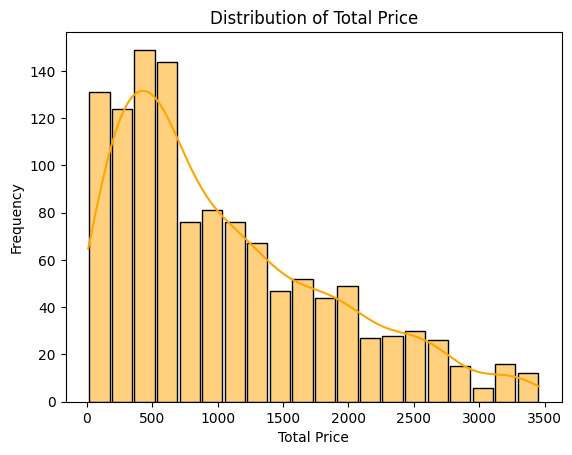

In [251]:
sns.histplot(df['TotalPrice'], bins=20,
          color='orange', edgecolor='black', kde = True, shrink=0.9
             )

plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")

plt.show()

## Insights

Most total prices are below 1000.
The distribution is right-skewed.
Highest frequency occurs around 300–700
Few high-value outliers are present above 2500

<Axes: xlabel='PaymentMethod', ylabel='TotalPrice'>

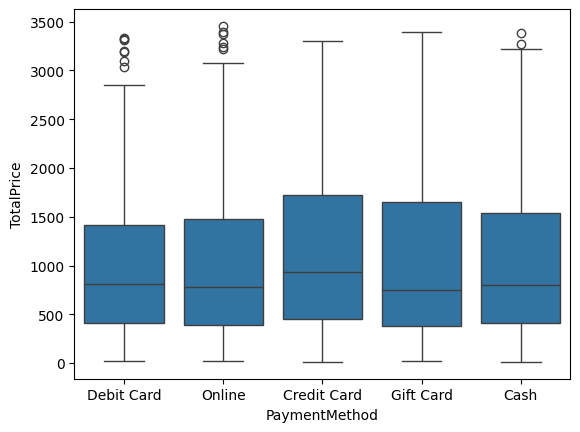

In [205]:
sns.boxplot(data=df,x='PaymentMethod', y='TotalPrice')

In [206]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[
    (df['TotalPrice'] >= lower_bound) &
    (df['TotalPrice'] <= upper_bound)
]

print("Original Shape:", df.shape)
print("New Shape:", df_no_outliers.shape)

Original Shape: (1200, 17)
New Shape: (1192, 17)


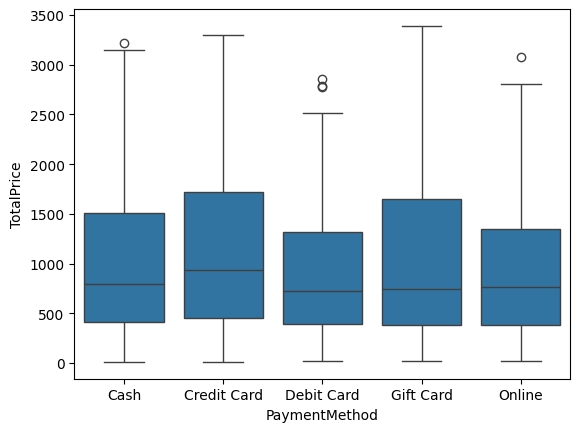

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_no_outliers,
    x=df_no_outliers['PaymentMethod'],
    y=df_no_outliers['TotalPrice']
)

plt.show()

iii. Countplot

<Axes: xlabel='Product', ylabel='count'>

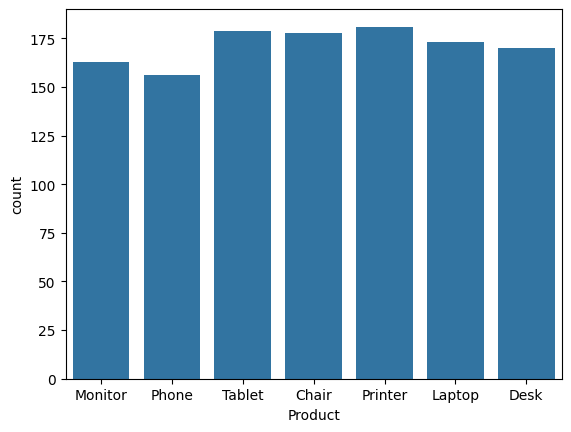

In [261]:


sns.countplot(x=df['Product'])

Insights:  tablet, chair product and printer are more in number for sales than the other products

2. univarite analysis and visualiztion

i. Trend Analysis

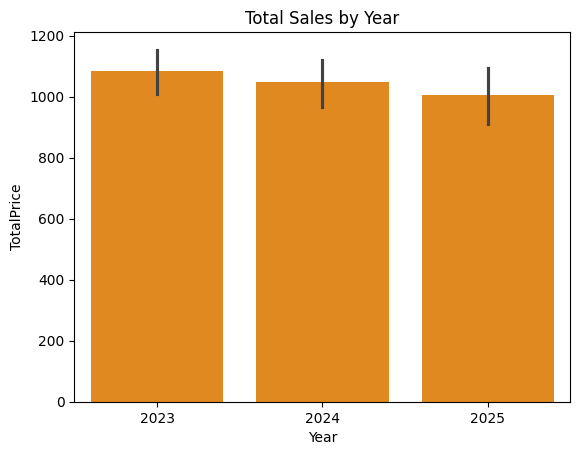

In [222]:

sns.barplot(data=df, x='Year', y='TotalPrice', color='darkorange')
plt.title("Total Sales by Year")
plt.show()

Insights: In the first year which is 2023 the total price or sales for certain company was higher and in the next two year the price slightly decrease to around 950.

ii. barplot

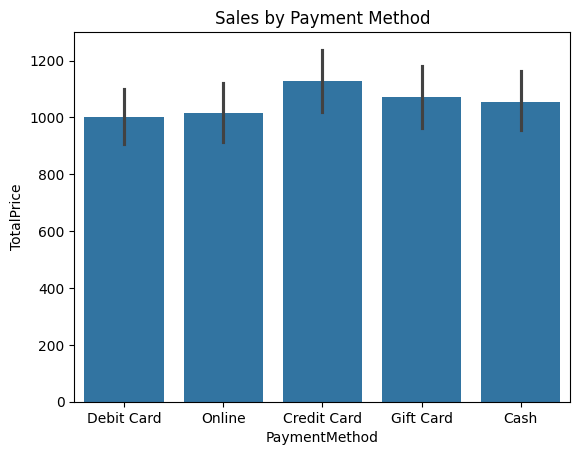

In [223]:
sns.barplot(data=df, x='PaymentMethod', y='TotalPrice')

plt.title("Sales by Payment Method")
plt.show()

Insights: Most of the prodcts was purchased using credit card. On the other hand, debit card was less used than the other payment method.

iii. lineplot

In [303]:
year = df['Year'].value_counts()
year


Year
2023    510
2024    459
2025    231
Name: count, dtype: int64

In [300]:
price = df.groupby('Year')['TotalPrice'].sum()
price

Year
2023    552643.24
2024    480235.87
2025    231882.85
Name: TotalPrice, dtype: float64

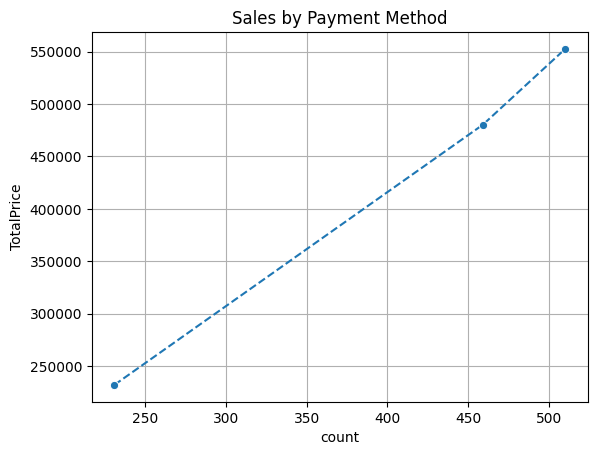

In [310]:
sns.lineplot(data=df, x=year, y=price, linestyle='--', marker='o')

plt.grid(True)
plt.title("Sales by Payment Method")
plt.show()

3. Bivariate analysis  and visualization

i. Correlation Analysis

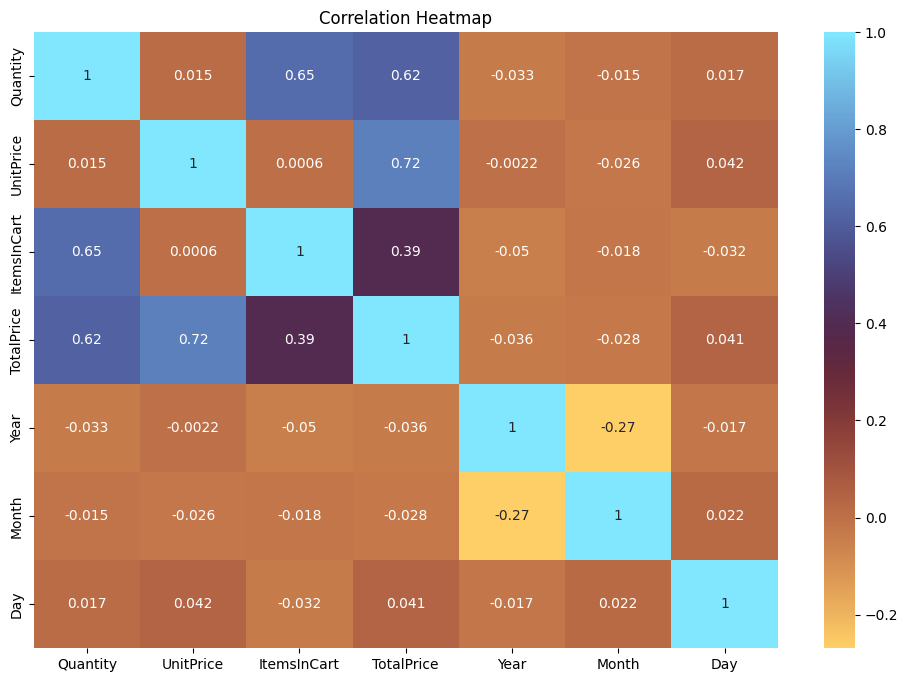

In [259]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='managua')

plt.title("Correlation Heatmap")
plt.show()

Correlation Heatmap Insights

TotalPrice increases when Quantity increases.
TotalPrice also increases when UnitPrice increases.
Customers who add more ItemsInCart usually buy more products.

MAIN INSIGHTS - There are no strong negative relationships in the data.

ii. Pair plot

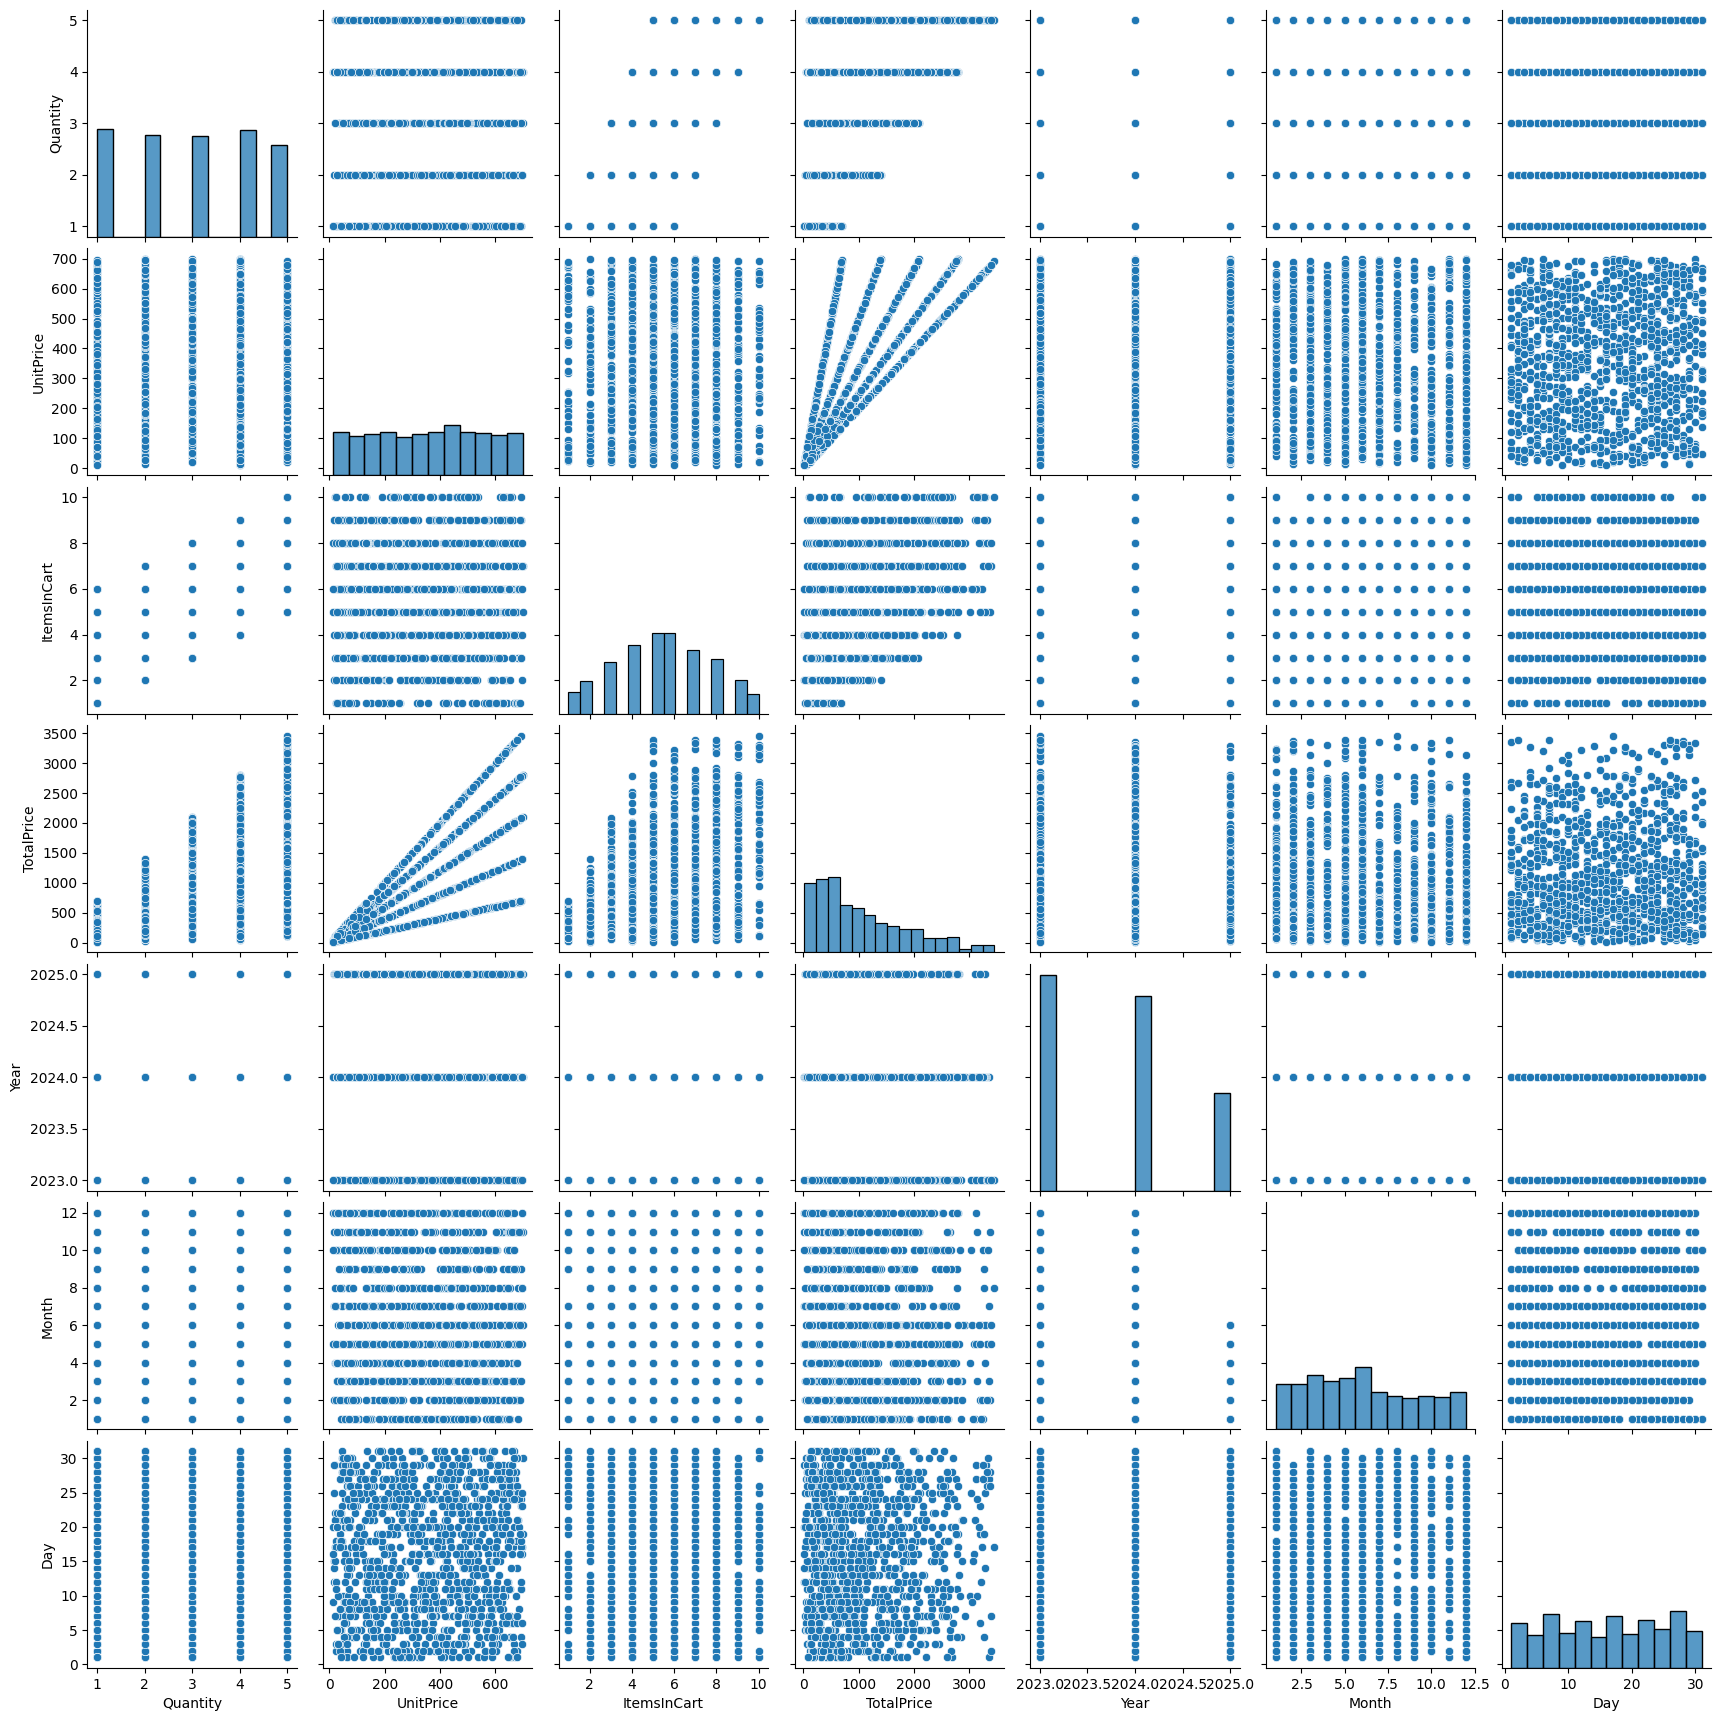

In [260]:
sns.pairplot(df)
plt.show()

Insights - Diagonal plots show the distribution of each variable and Off-diagonal plots show relationships (correlation) between variables